In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
data = r'C:\Users\Noman khan\Downloads\archive (2)\Housing.csv'
df = pd.read_csv(data)

print(df.head())
print(df.info())
print(df.columns)
print(df.dtypes)
#print(df.describe())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [6]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea']
for cols in binary_cols:
    if df[cols].dtype == "object":

        df[cols] = df[cols].str.lower().str.strip().map({"yes":1, "no":0})

df_final = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)
print(df_final.select_dtypes(include=object).columns)
print(df_final.isnull().sum())
X = df_final.drop('price', axis=1)
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

Index([], dtype='object')
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)


In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)

MAE:  970043.4039201637
MSE:  1754318687330.6638
RMSE:  1324506.9600914386


In [28]:
r2score = r2_score(y_test, y_pred)
print(f"R2 Score: {r2score:.2f} ")

R2 Score: 0.65 


In [10]:
y_mean = np.mean(y_test)
percentage_error = (rmse/y_mean) * 100
print(f"Average Target Value:  {y_mean:,.2f}")
print(f"RMSE as % of Average: {percentage_error:.2f}")




Average Target Value:  5,007,536.70
RMSE as % of Average: 26.45


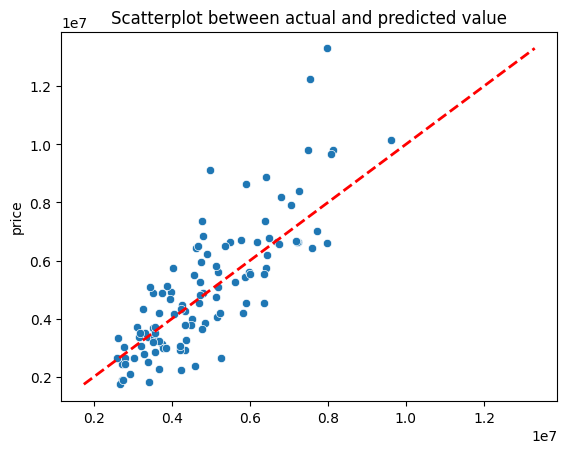

In [11]:
sns.scatterplot(x=y_pred, y=y_test)
plt.title("Scatterplot between actual and predicted value")
max_val = max(np.max(y_test), np.max(y_pred))
min_val = min(np.min(y_test), np.min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", lw=2)
plt.show()

## R2 Score for Non-Technical People
Our model successfully explains 65.3% of why prices vary. It understands the main factors driving most price changes. The remaining 35% comes from missing information or unpredictable real-world details. Think of it as a solid, reliable guide that captures the big picture but misses some specific nuanc 

## Ensemble Learning: Random Forest vs XGBoost


In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [13]:
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [14]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [20]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("Result of RandomForestRegressor")

print(f"MAE:{rf_mae:.2f} ")
print(f"MSE:{rf_mse:.2f} ")
print(f"RMSE:{rf_rmse:.2f} ")

Result of RandomForestRegressor
MAE:1022560.05 
MSE:1964193399645.33 
RMSE:1401496.84 


In [22]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)

print("Result of XGBRegressor")
print(f"MAE:{xgb_mae:.2f} ")
print(f"MSE:{xgb_mse:.2f} ")
print(f"RMSE:{xgb_rmse:.2f} ")

Result of XGBRegressor
MAE:1053537.75 
MSE:2075265597440.00 
RMSE:1440578.22 


In [26]:
comparison = pd.DataFrame({
    "model" : ["LinearRegression(baseline)", "RandomForestRegressor", "XGBRegressor"],
    "MAE":   [mae, rf_mae, xgb_mae],
    "MSE": [mse, rf_mse, xgb_mse],
    "RMSE": [rmse, rf_rmse, xgb_rmse]
})

print(comparison)
print(df['price'].describe())
print(y.describe())

                        model           MAE           MSE          RMSE
0  LinearRegression(baseline)  9.700434e+05  1.754319e+12  1.324507e+06
1       RandomForestRegressor  1.022560e+06  1.964193e+12  1.401497e+06
2                XGBRegressor  1.053538e+06  2.075266e+12  1.440578e+06
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


In [27]:
rf_r2 = r2_score(y_test, rf_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"RF R2: {rf_r2:.2f}")
print(f"xgb R2: {xgb_r2:.2f}")

RF R2: 0.61
xgb R2: 0.59


In [30]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
xgb_importance =  pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(xgb_importance)


bathrooms                          0.323528
airconditioning                    0.131264
furnishingstatus_unfurnished       0.086995
area                               0.080922
hotwaterheating                    0.072116
basement                           0.054031
prefarea                           0.053034
guestroom                          0.039399
bedrooms                           0.039354
stories                            0.039090
mainroad                           0.035141
parking                            0.030044
furnishingstatus_semi-furnished    0.015081
dtype: float32


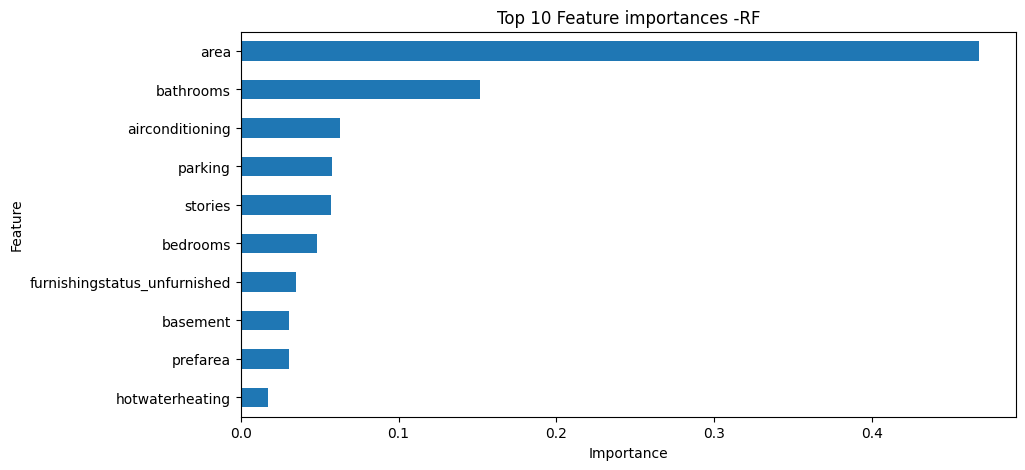

In [39]:
plt.figure(figsize=(10, 5))
rf_importance.head(10).plot(kind="barh")
plt.title("Top 10 Feature importances -RF")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

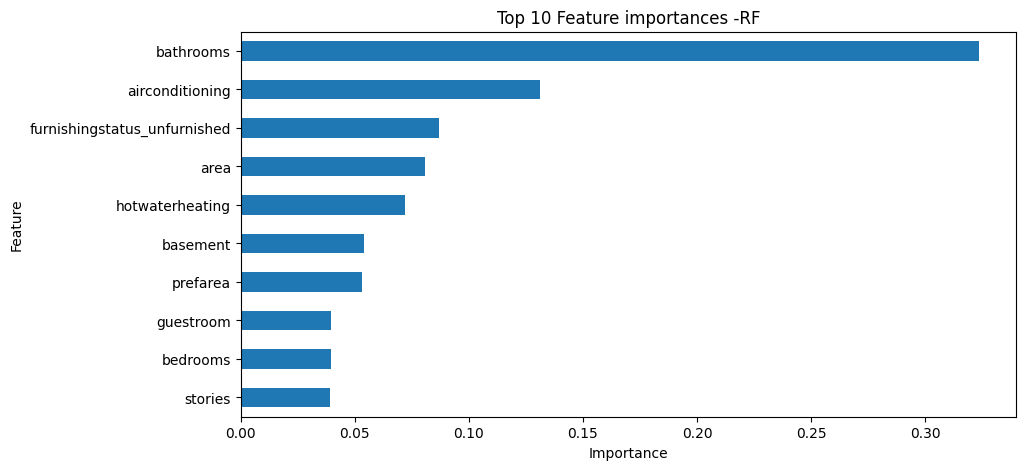

In [41]:
plt.figure(figsize=(10, 5))
xgb_importance.head(10).plot(kind="barh")
plt.title("Top 10 Feature importances -RF")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

## Random Forest

Random Forest combines many decision trees and trains them independently on different random samples of the data and features. It combines their predictions, typically by averaging them for regression, to produce a more stable and accurate prediction.

## XGBoost
XGBoost builds decision trees sequentially, where each new tree focuses on correcting the errors made by the previous trees. It combines the predictions of all the trees to create a strong final model.

Core difference: Random Forest = trees independently + average. XGBoost = trees sequentially + correct errors.